# FontSense full-dataset EDA and quality audit

This notebook audits the existing 3,600-image dataset and frozen
family split. It does **not** generate images and does **not** train
or evaluate a model.

## tl;dr

- The dataset has 3,600 images, 90 independent font families, and
  exactly balanced category counts.
- All listed images open at 224×96 pixels. The automated screen
  finds no missing, corrupt, blank, or extremely low-contrast files.
- No font family crosses train, validation, and test.
- Backgrounds, selected effects, and rendered phrases follow the
  same schedule in every category.
- No exact file duplicates or extremely near-identical pairs are
  found under the documented strict checks.
- These are data-quality findings, not model-performance results.

## Context & Methods

**Unit of observation:** one manifest row represents one rendered
image. `image_path` is the candidate key.

The audit checks manifest counts, frozen assignments, file
readability, dimensions, grayscale brightness and contrast,
generation metadata, SHA-256 hashes, and a strict near-duplicate
screen. The near-duplicate screen requires a 16×16 difference-hash
Hamming distance of at most 2 and structural similarity of at least
0.995.

“Unreadable” cannot be proved from one simple numeric rule. The
automated flag therefore covers missing, corrupt, blank, and
extremely low-contrast images. The saved sample grids support human
review of subjective readability.

Test images are included only in the requested structural and
quality checks. No model choice or hyperparameter is made here.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image as NotebookImage, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "AGENTS.md").is_file():
    raise RuntimeError("Run this notebook from the FontSense repository root.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fontsense.eda import run_eda

MANIFEST_PATH = ROOT / "reports/dataset/full_manifest.csv"
FROZEN_SPLIT_PATH = ROOT / "data/interim/google_fonts_final_family_split.csv"
OUTPUT_DIR = ROOT / "reports/eda"
FIGURE_DIR = ROOT / "reports/figures"
pd.set_option("display.max_columns", 30)

In [2]:
summary = run_eda(
    manifest_path=MANIFEST_PATH,
    frozen_split_path=FROZEN_SPLIT_PATH,
    output_dir=OUTPUT_DIR,
    figure_dir=FIGURE_DIR,
    root=ROOT,
)
print("EDA status:", summary["status"])
print("Dataset ready for model training:", summary["dataset_ready_for_model_training"])

EDA status: passed
Dataset ready for model training: True


## Data

The source manifest is the frozen, committed 3,600-row record from
dataset generation. The family split is independently loaded and
compared with the manifest. The audit never creates a new split.

In [3]:
manifest = pd.read_csv(MANIFEST_PATH, keep_default_na=False)
frozen_split = pd.read_csv(FROZEN_SPLIT_PATH, keep_default_na=False)
counts = pd.read_csv(OUTPUT_DIR / "dataset_counts.csv")
display(counts)
print("Manifest SHA-256:", summary["source_manifest_sha256"])
print("Frozen split SHA-256:", summary["frozen_split_sha256"])

,category,split,images,families
0,display,test,120,3
1,display,train,480,12
2,display,validation,120,3
3,handwriting,test,120,3
4,handwriting,train,480,12
5,handwriting,validation,120,3
6,monospace,test,120,3
7,monospace,train,480,12
8,monospace,validation,120,3
9,sans_serif,test,120,3


Manifest SHA-256: 93afae99ea6ac7dc65e8cf03a1e5743f9581c189f1feaf115ad7439fad58d69c
Frozen split SHA-256: f6cdd858449a4143993b051e9de83578cd423544135dbf6cc17f004359d2e17b


**Conclusion.** The manifest keeps one row per image, all 90 frozen
families are present, and each family has exactly 40 images.

## Results

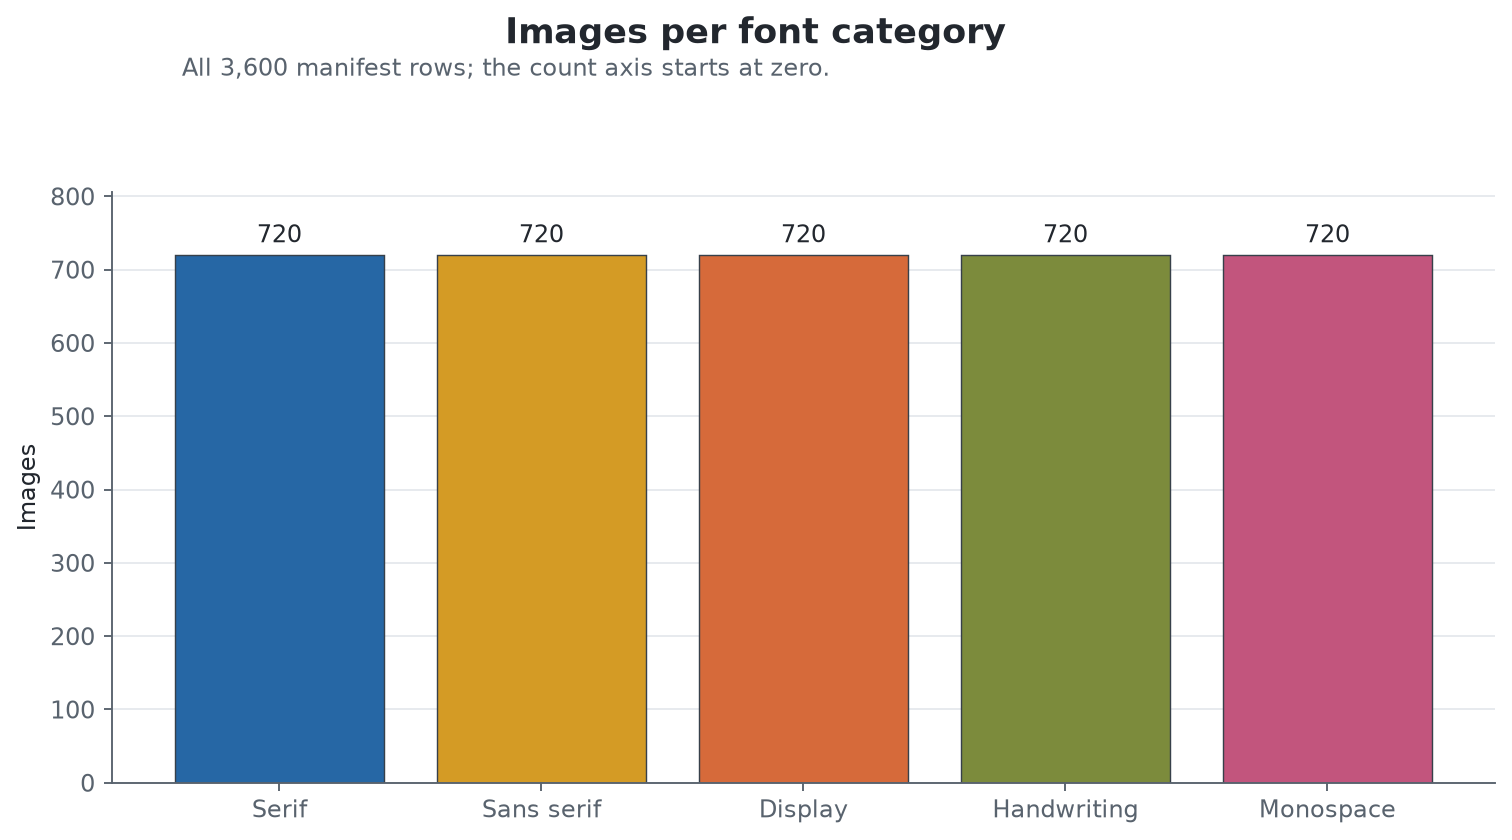

In [4]:
display(NotebookImage(filename=str(FIGURE_DIR / "class_counts.png")))

In [5]:
display(Markdown(
    "**Conclusion.** Every category contains exactly "
    f"{next(iter(summary['structure']['images_per_category'].values())):,} images, "
    "so the target classes are exactly balanced."
))

**Conclusion.** Every category contains exactly 720 images, so the target classes are exactly balanced.

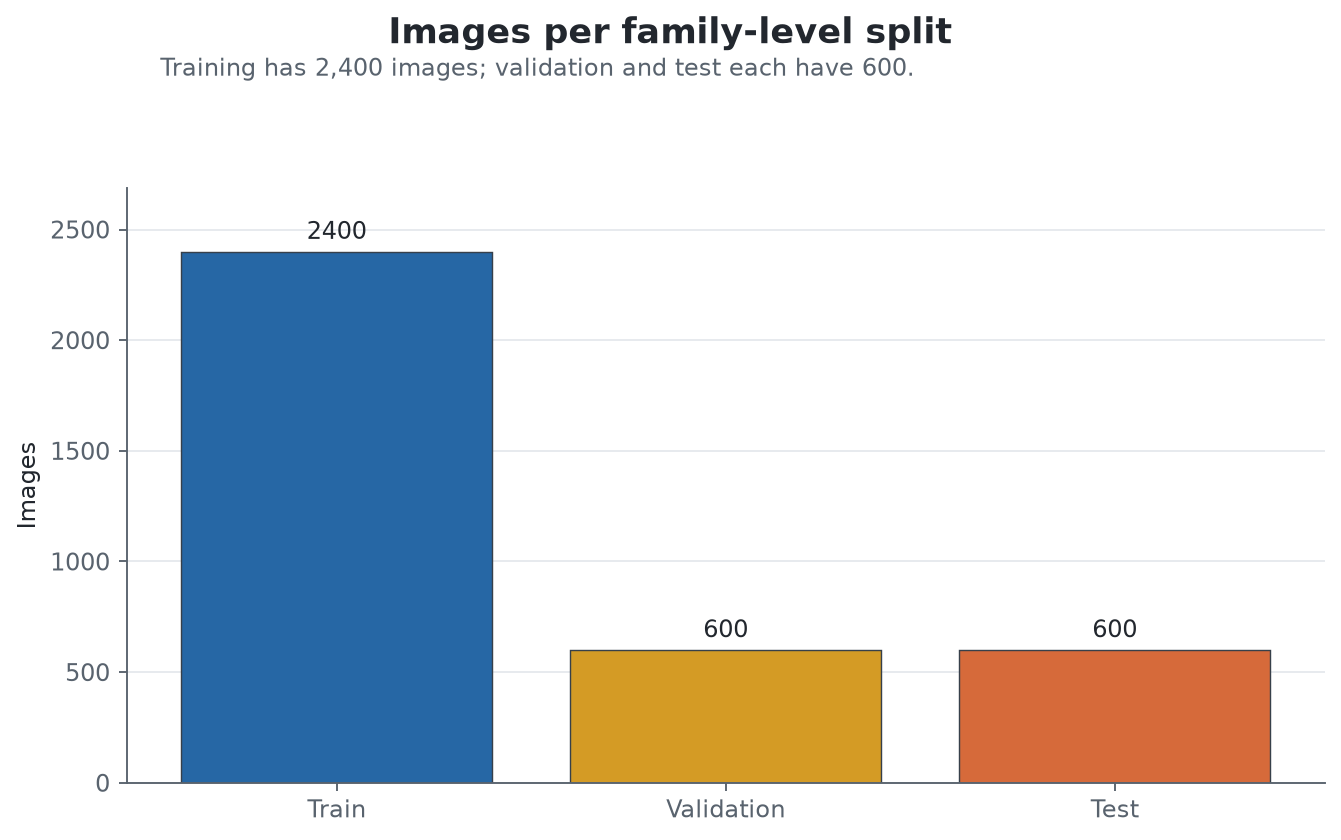

In [6]:
display(NotebookImage(filename=str(FIGURE_DIR / "split_counts.png")))

In [7]:
split_counts = summary["structure"]["images_per_split"]
display(Markdown(
    "**Conclusion.** The family-level split contains "
    f"{split_counts['train']:,} train, {split_counts['validation']:,} validation, "
    f"and {split_counts['test']:,} test images."
))

**Conclusion.** The family-level split contains 2,400 train, 600 validation, and 600 test images.

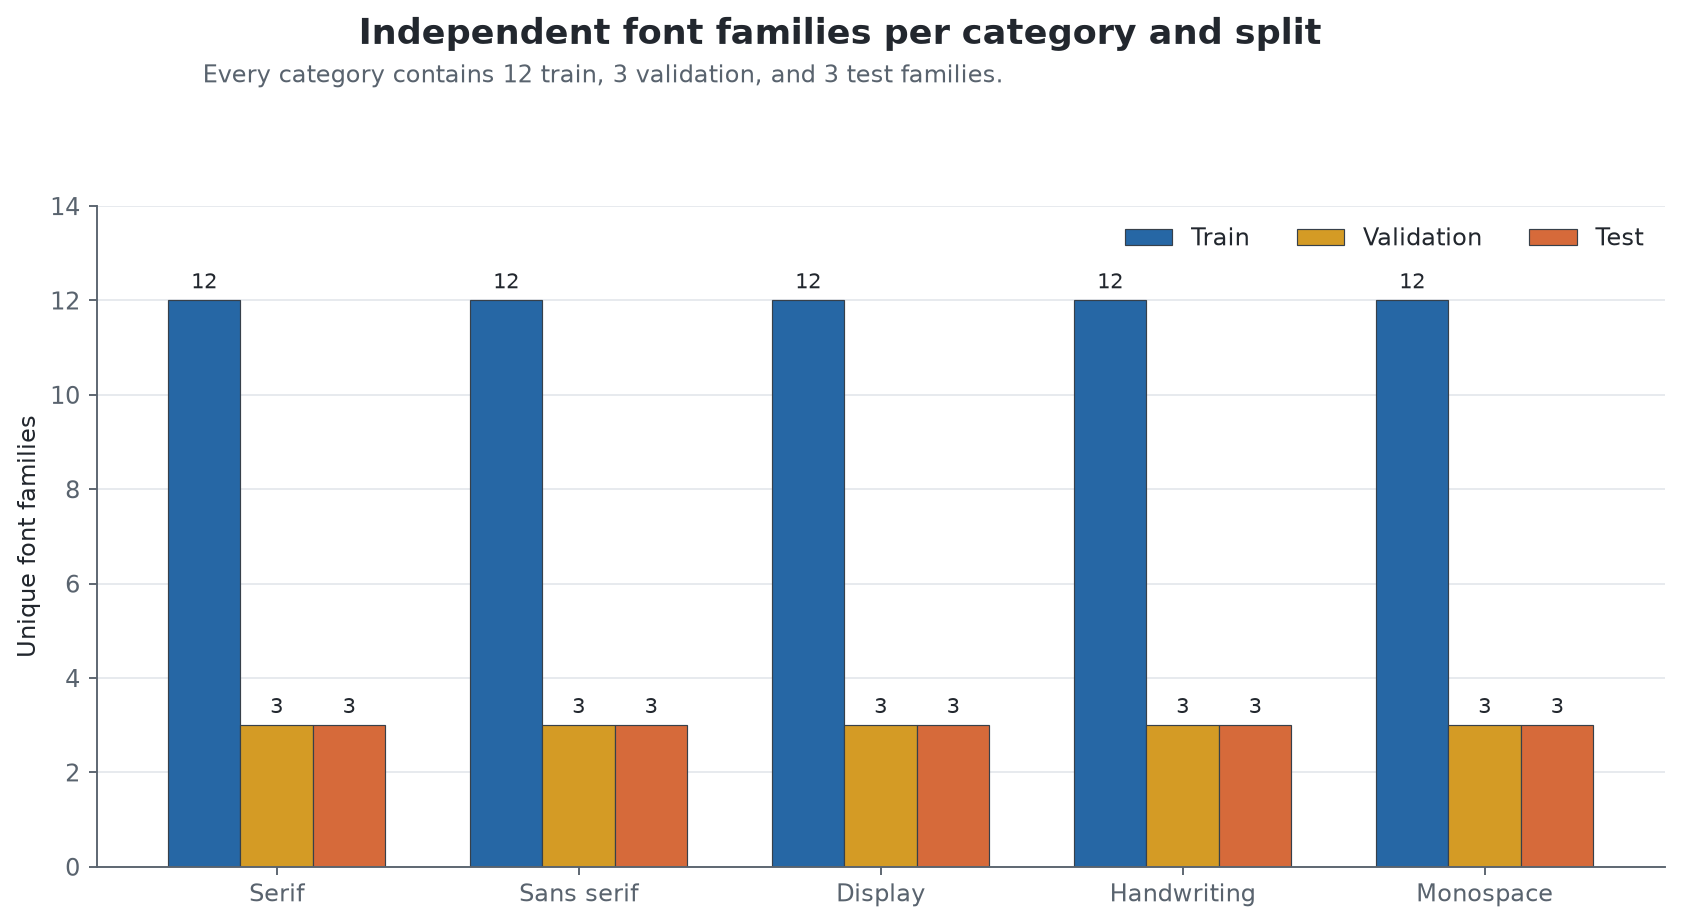

In [8]:
display(NotebookImage(filename=str(FIGURE_DIR / "families_per_category_split.png")))

In [9]:
display(Markdown(
    "**Conclusion.** Every category has 12 train, 3 validation, and "
    "3 test families. The overlap check found "
    f"**{summary['structure']['family_overlap_count']}** families in more than one split."
))

**Conclusion.** Every category has 12 train, 3 validation, and 3 test families. The overlap check found **0** families in more than one split.

### Image quality

brightness_mean                 contrast_std              
                        min  median     max          min median    max
category                                                              
display               18.10  230.34  246.20        17.65  38.56  76.27
handwriting           11.26  236.73  251.60         7.52  21.93  56.69
monospace             12.34  235.92  250.15        10.96  25.46  53.74
sans_serif            12.88  235.76  250.33        11.32  25.77  52.51
serif                 11.49  236.00  249.23        10.27  25.19  50.94

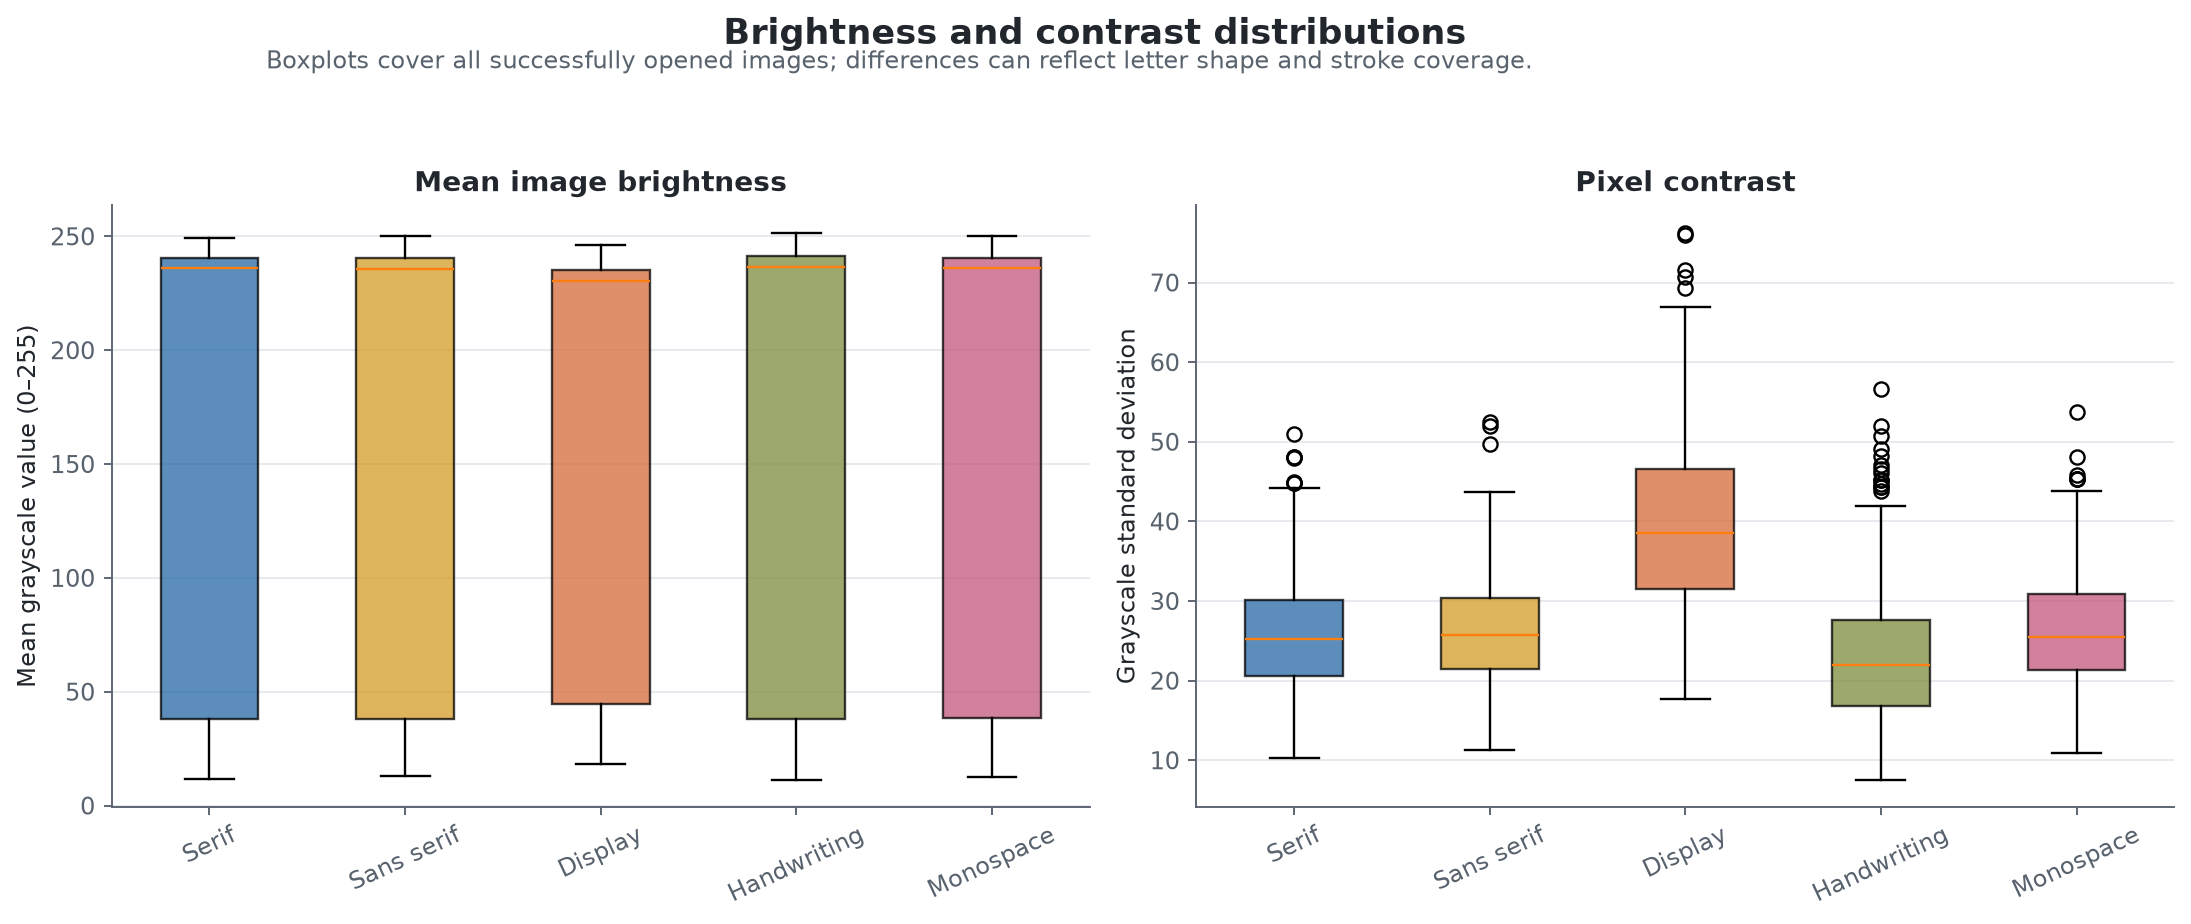

In [10]:
quality = pd.read_csv(OUTPUT_DIR / "image_quality_metrics.csv")
display(
    quality.groupby("category")[["brightness_mean", "contrast_std"]]
    .agg(["min", "median", "max"])
    .round(2)
)
display(NotebookImage(filename=str(FIGURE_DIR / "brightness_contrast_distributions.png")))

In [11]:
image_quality = summary["image_quality"]
display(Markdown(
    "**Conclusion.** All "
    f"{image_quality['images_opened_successfully']:,} images opened at 224×96. "
    f"Missing: {image_quality['missing_images']}; corrupt: {image_quality['corrupted_images']}; "
    f"blank: {image_quality['blank_images']}; automated extremely low-contrast flags: "
    f"{image_quality['low_pixel_contrast_flags']}."
))

**Conclusion.** All 3,600 images opened at 224×96. Missing: 0; corrupt: 0; blank: 0; automated extremely low-contrast flags: 0.

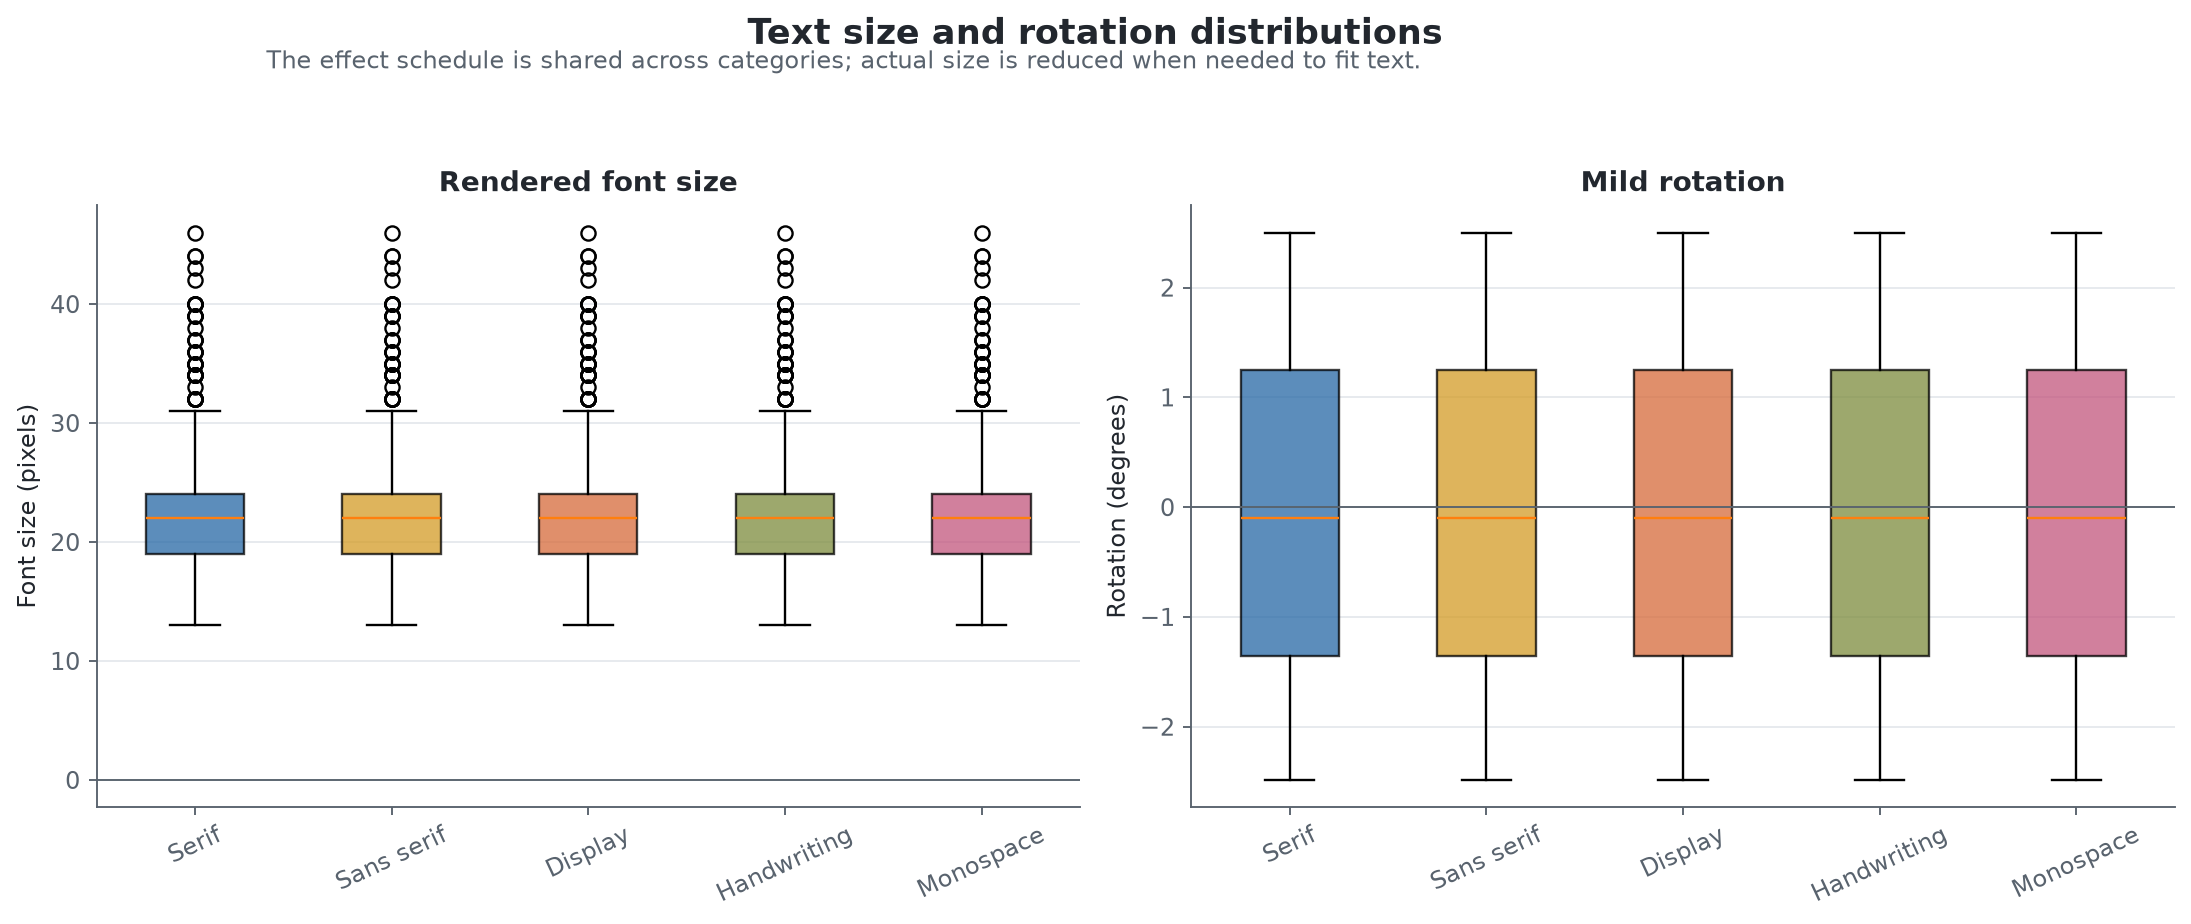

In [12]:
display(NotebookImage(filename=str(FIGURE_DIR / "text_size_rotation_distributions.png")))

In [13]:
text_size = summary["text_size"]
rotation = summary["effects"]["rotation_range_degrees"]
display(Markdown(
    "**Conclusion.** Actual rendered font sizes range from "
    f"{text_size['minimum_actual_font_size']} to {text_size['maximum_actual_font_size']} pixels "
    f"(median {text_size['median_actual_font_size']:.0f}). Rotation stays between "
    f"{rotation[0]:.3f}° and {rotation[1]:.3f}°."
))

**Conclusion.** Actual rendered font sizes range from 13 to 46 pixels (median 22). Rotation stays between -2.485° and 2.500°.

### Leakage, effects, and phrase balance

,category,dark_background,soft_contrast,blur_applied,jpeg_applied,letter_spacing_applied,rotation_applied,horizontal_shift_applied,vertical_shift_applied,scaling_applied,actual_font_size,rotation_degrees,blur_radius,jpeg_quality
0,display,0.2847,0.3667,0.2417,0.2569,0.7528,1.0,0.9542,0.8944,1.0,22.4028,-0.049,0.3114,81.8865
1,handwriting,0.2847,0.3667,0.2417,0.2569,0.7528,1.0,0.9542,0.8944,1.0,22.4028,-0.049,0.3114,81.8865
2,monospace,0.2847,0.3667,0.2417,0.2569,0.7528,1.0,0.9542,0.8944,1.0,22.4028,-0.049,0.3114,81.8865
3,sans_serif,0.2847,0.3667,0.2417,0.2569,0.7528,1.0,0.9542,0.8944,1.0,22.4028,-0.049,0.3114,81.8865
4,serif,0.2847,0.3667,0.2417,0.2569,0.7528,1.0,0.9542,0.8944,1.0,22.4028,-0.049,0.3114,81.8865


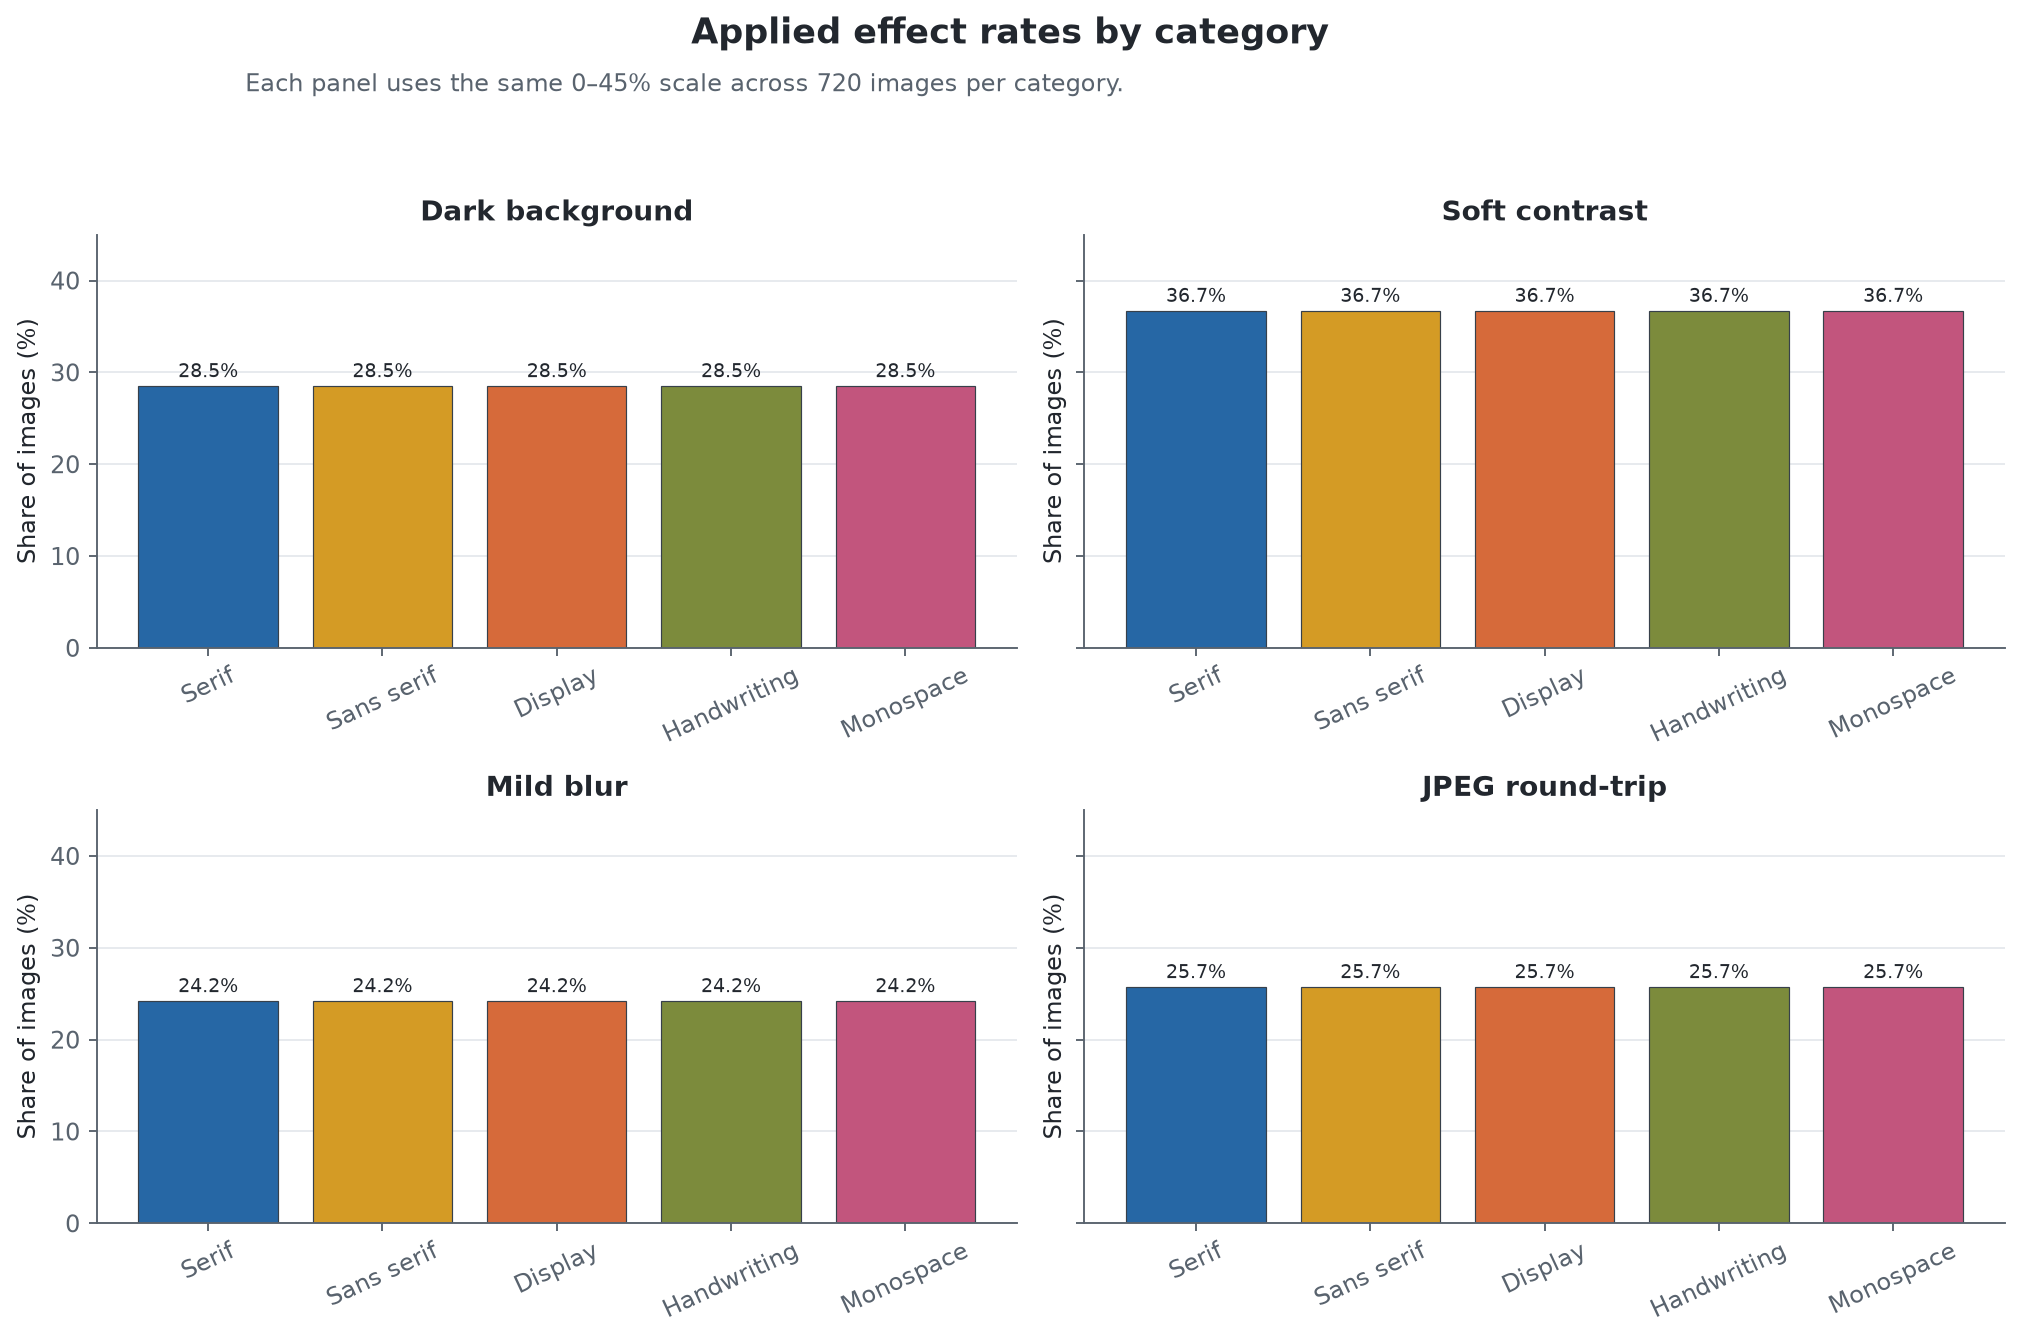

In [14]:
effect_balance = pd.read_csv(OUTPUT_DIR / "effect_balance_by_category.csv")
display(effect_balance.round(4))
display(NotebookImage(filename=str(FIGURE_DIR / "effect_distributions.png")))

In [15]:
display(Markdown(
    "**Conclusion.** The maximum binary effect-rate difference across categories is "
    f"{summary['effects']['maximum_binary_effect_rate_spread']:.1%}. "
    "There is no serious category-dependent effect imbalance."
))

**Conclusion.** The maximum binary effect-rate difference across categories is 0.0%. There is no serious category-dependent effect imbalance.

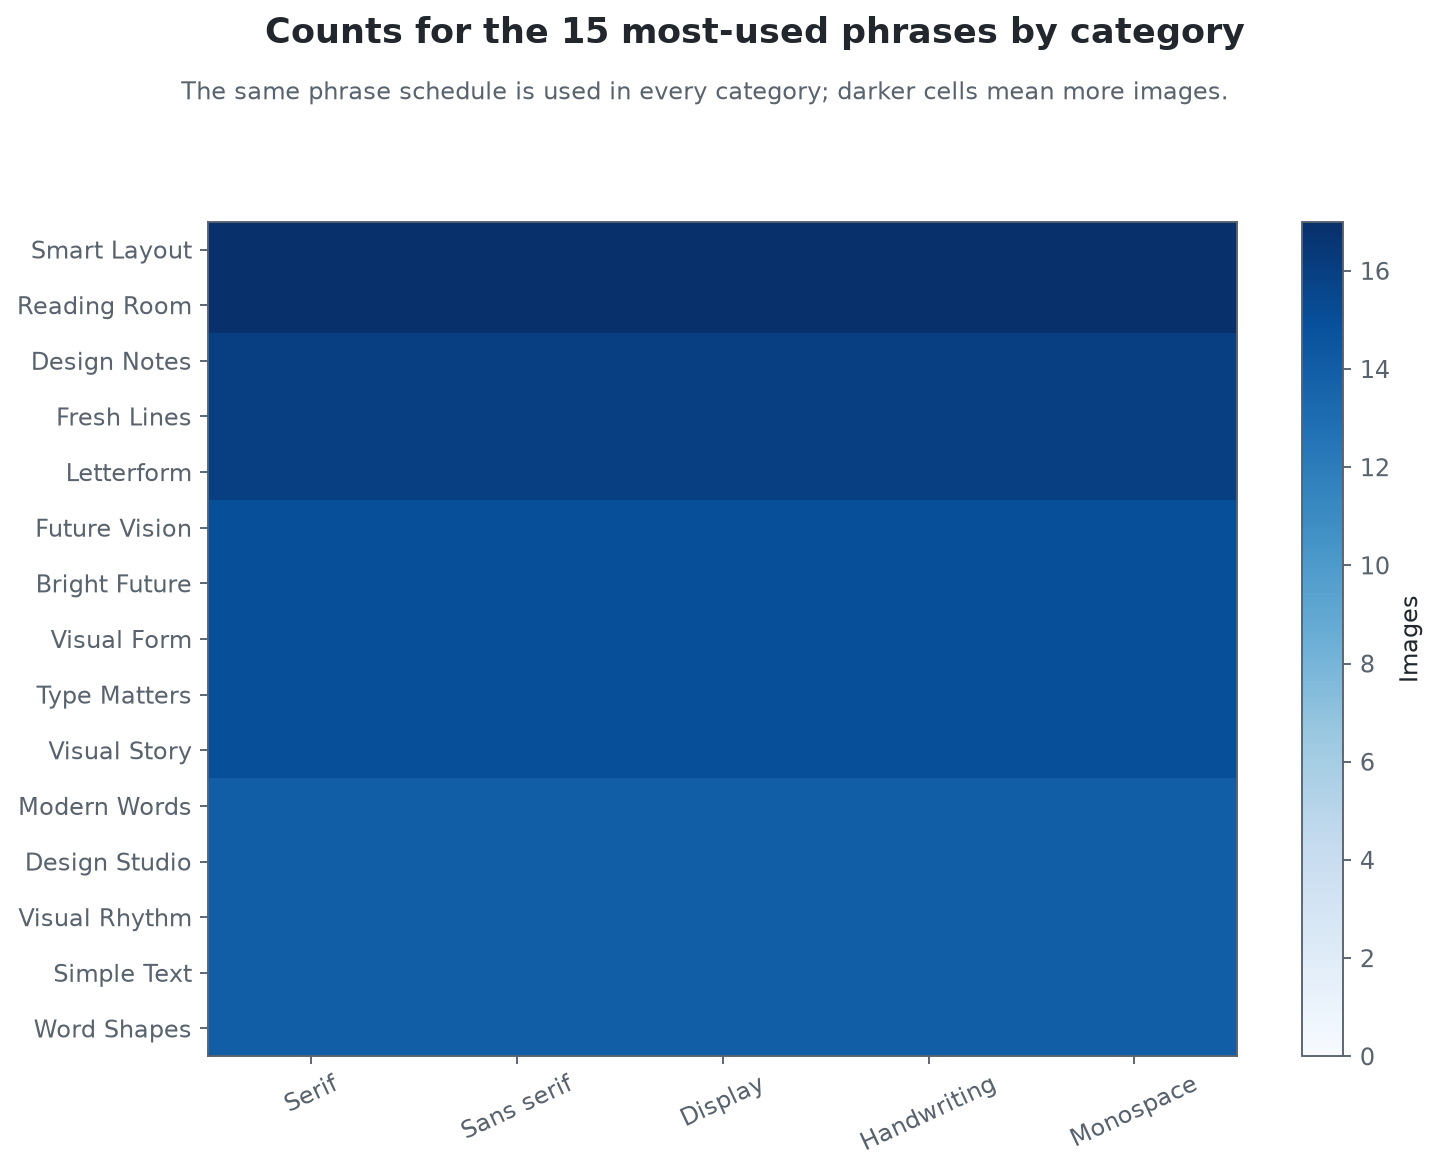

In [16]:
display(NotebookImage(filename=str(FIGURE_DIR / "phrase_category_balance.png")))

In [17]:
phrase = summary["phrase_balance"]
display(Markdown(
    "**Conclusion.** The dataset uses "
    f"{phrase['unique_phrases']} phrases. Cramér's V is {phrase['cramers_v']:.3f}, "
    "and the maximum category rate difference is "
    f"{phrase['maximum_phrase_rate_spread']:.1%}; phrases are not associated with one category."
))

**Conclusion.** The dataset uses 55 phrases. Cramér's V is 0.000, and the maximum category rate difference is 0.0%; phrases are not associated with one category.

In [18]:
suspicious = pd.read_csv(OUTPUT_DIR / "suspicious_image_pairs.csv")
display(Markdown(
    "**Duplicate check.** Exact duplicate hash groups: "
    f"{summary['image_quality']['exact_duplicate_hash_groups']}. "
    "Strict suspicious near-identical pairs: "
    f"{summary['image_quality']['suspicious_near_identical_pairs']}."
))
display(suspicious.head(10))

**Duplicate check.** Exact duplicate hash groups: 0. Strict suspicious near-identical pairs: 0.

,left_image_path,right_image_path,left_family,right_family,left_category,right_category,hash_hamming_distance,structural_similarity,exact_file_duplicate


**Model-feature check.** The HOG pipeline calculates features only
from grayscale pixels. The CNN receives only normalized image
tensors. Paths are used to open files, `category` is the target, and
file names, family, split, phrase, source font, random seed, and
effect metadata are not passed to either model as features.

### Representative and difficult examples

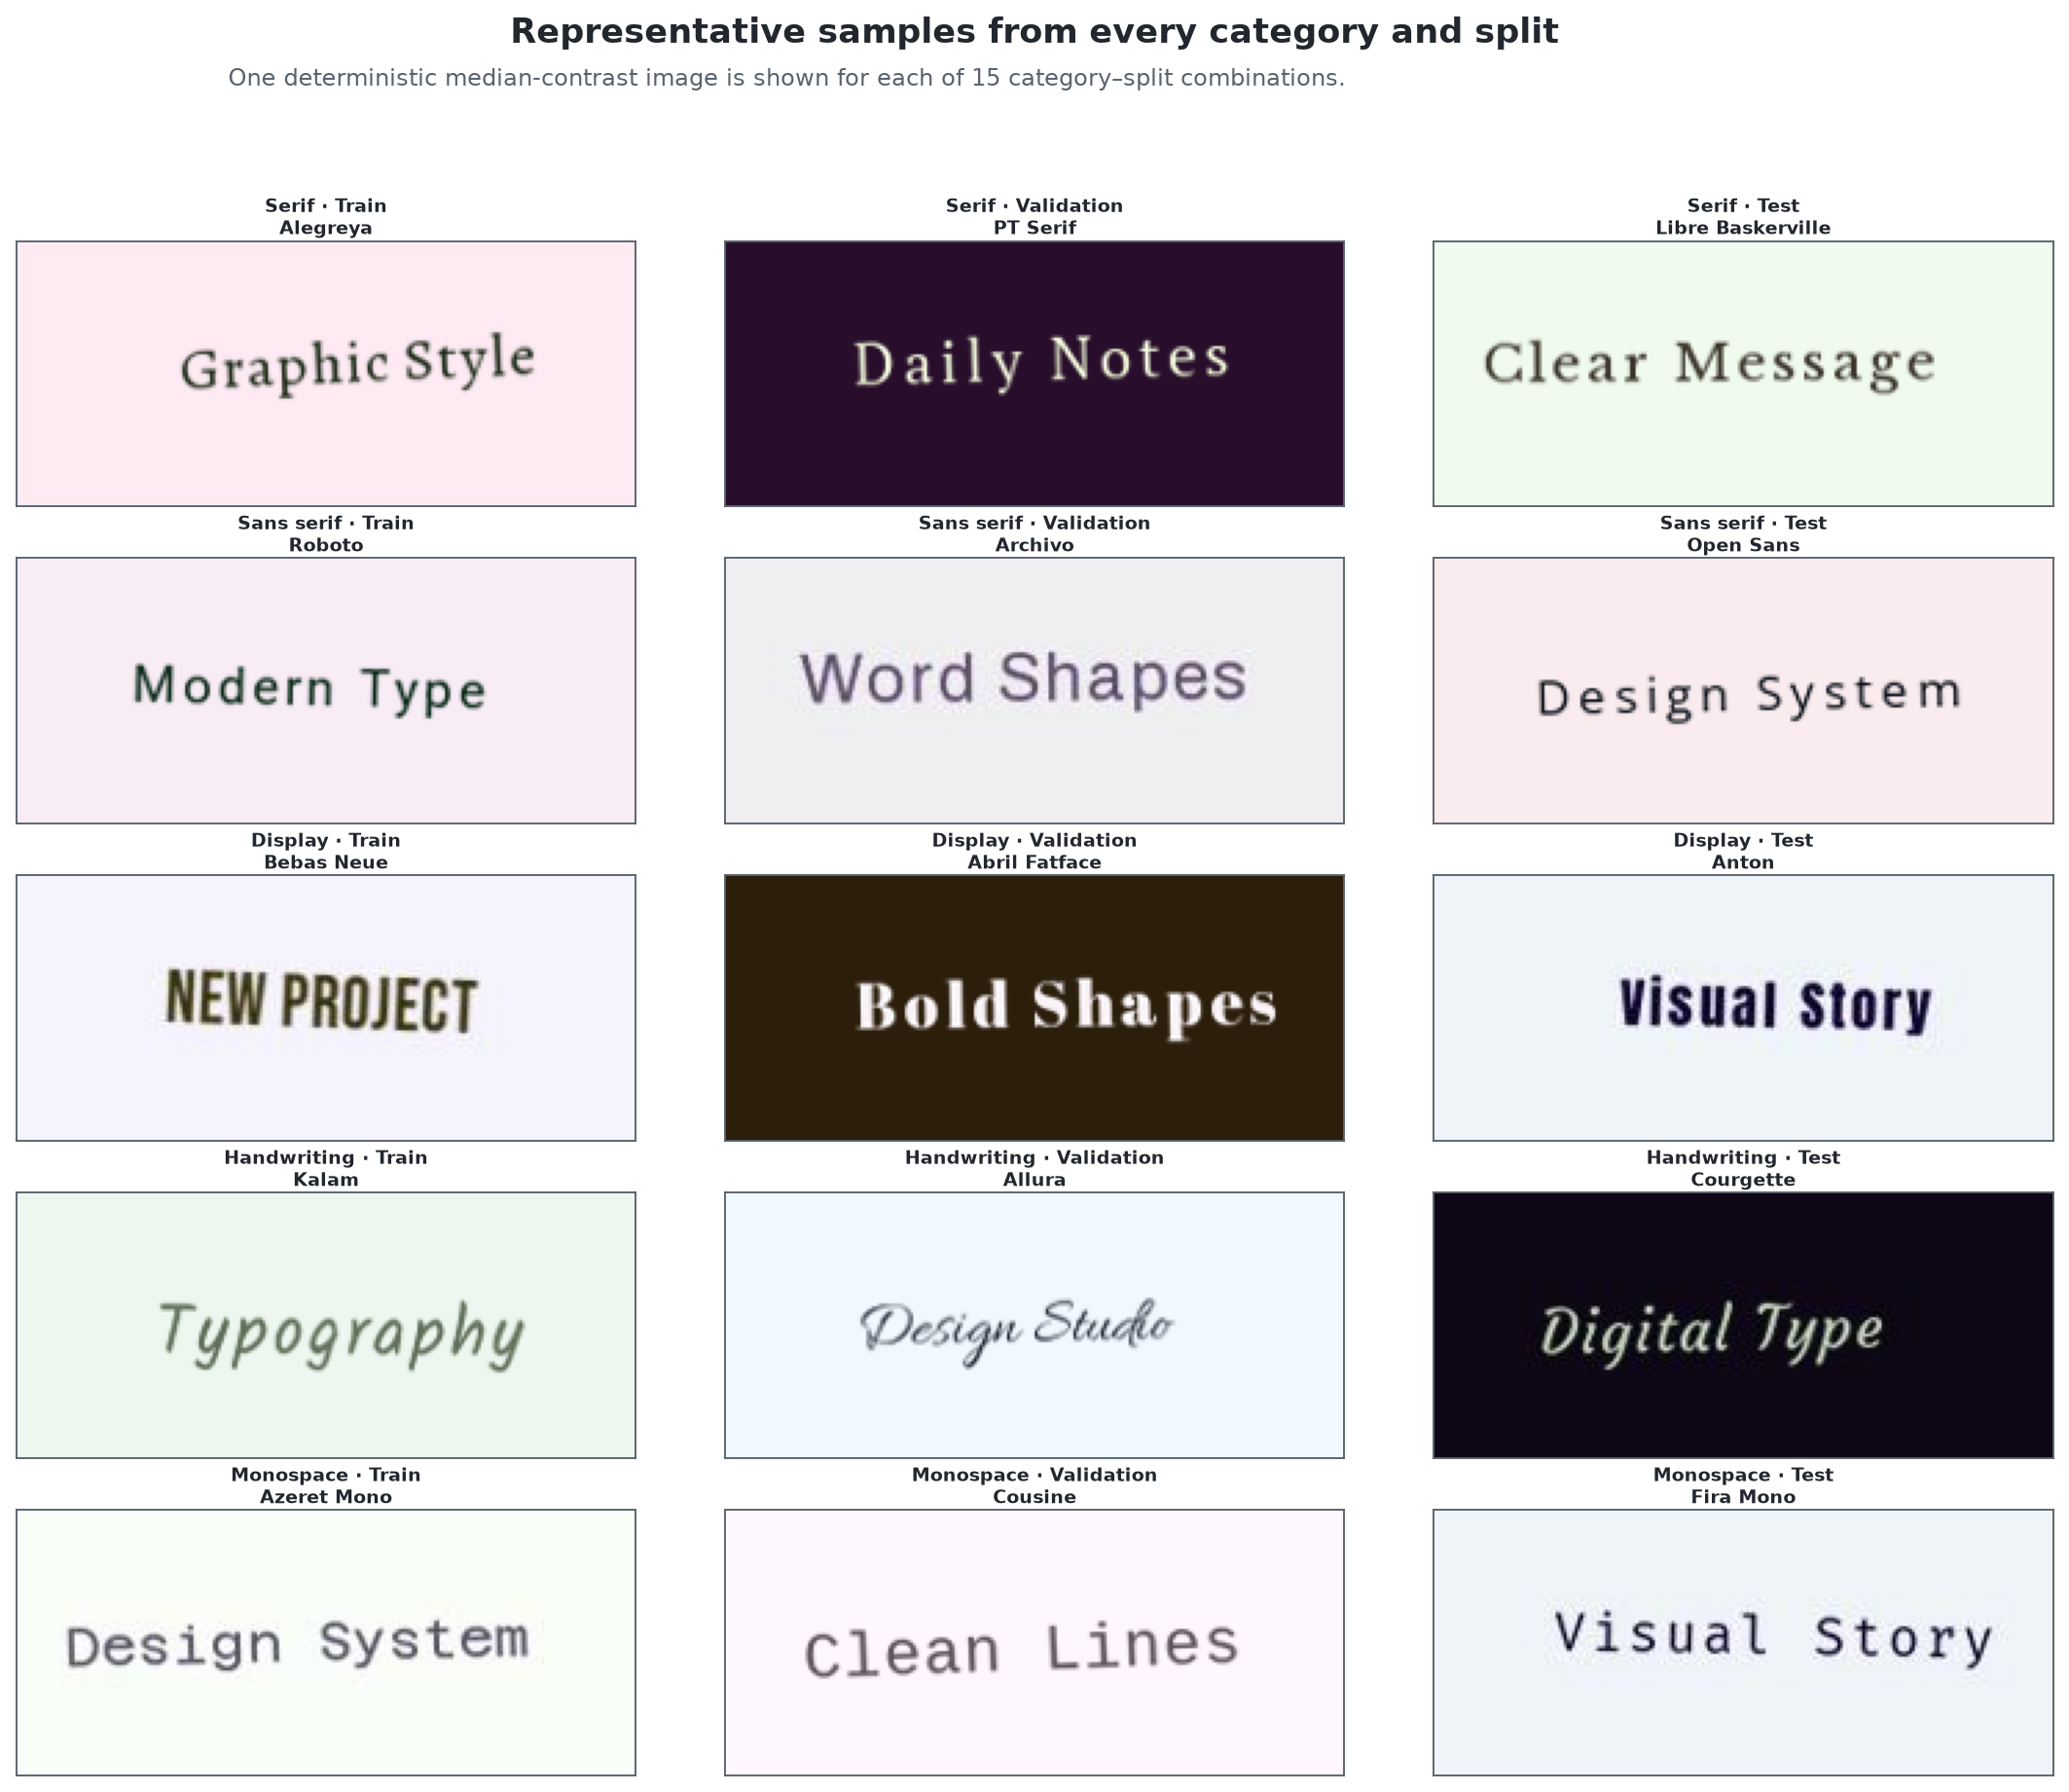

In [19]:
display(NotebookImage(filename=str(FIGURE_DIR / "representative_samples.png")))

In [20]:
display(Markdown(
    "**Conclusion.** The grid includes one deterministic median-contrast "
    "example from every category and split. It confirms that the saved "
    "images contain readable text across the requested combinations."
))

**Conclusion.** The grid includes one deterministic median-contrast example from every category and split. It confirms that the saved images contain readable text across the requested combinations.

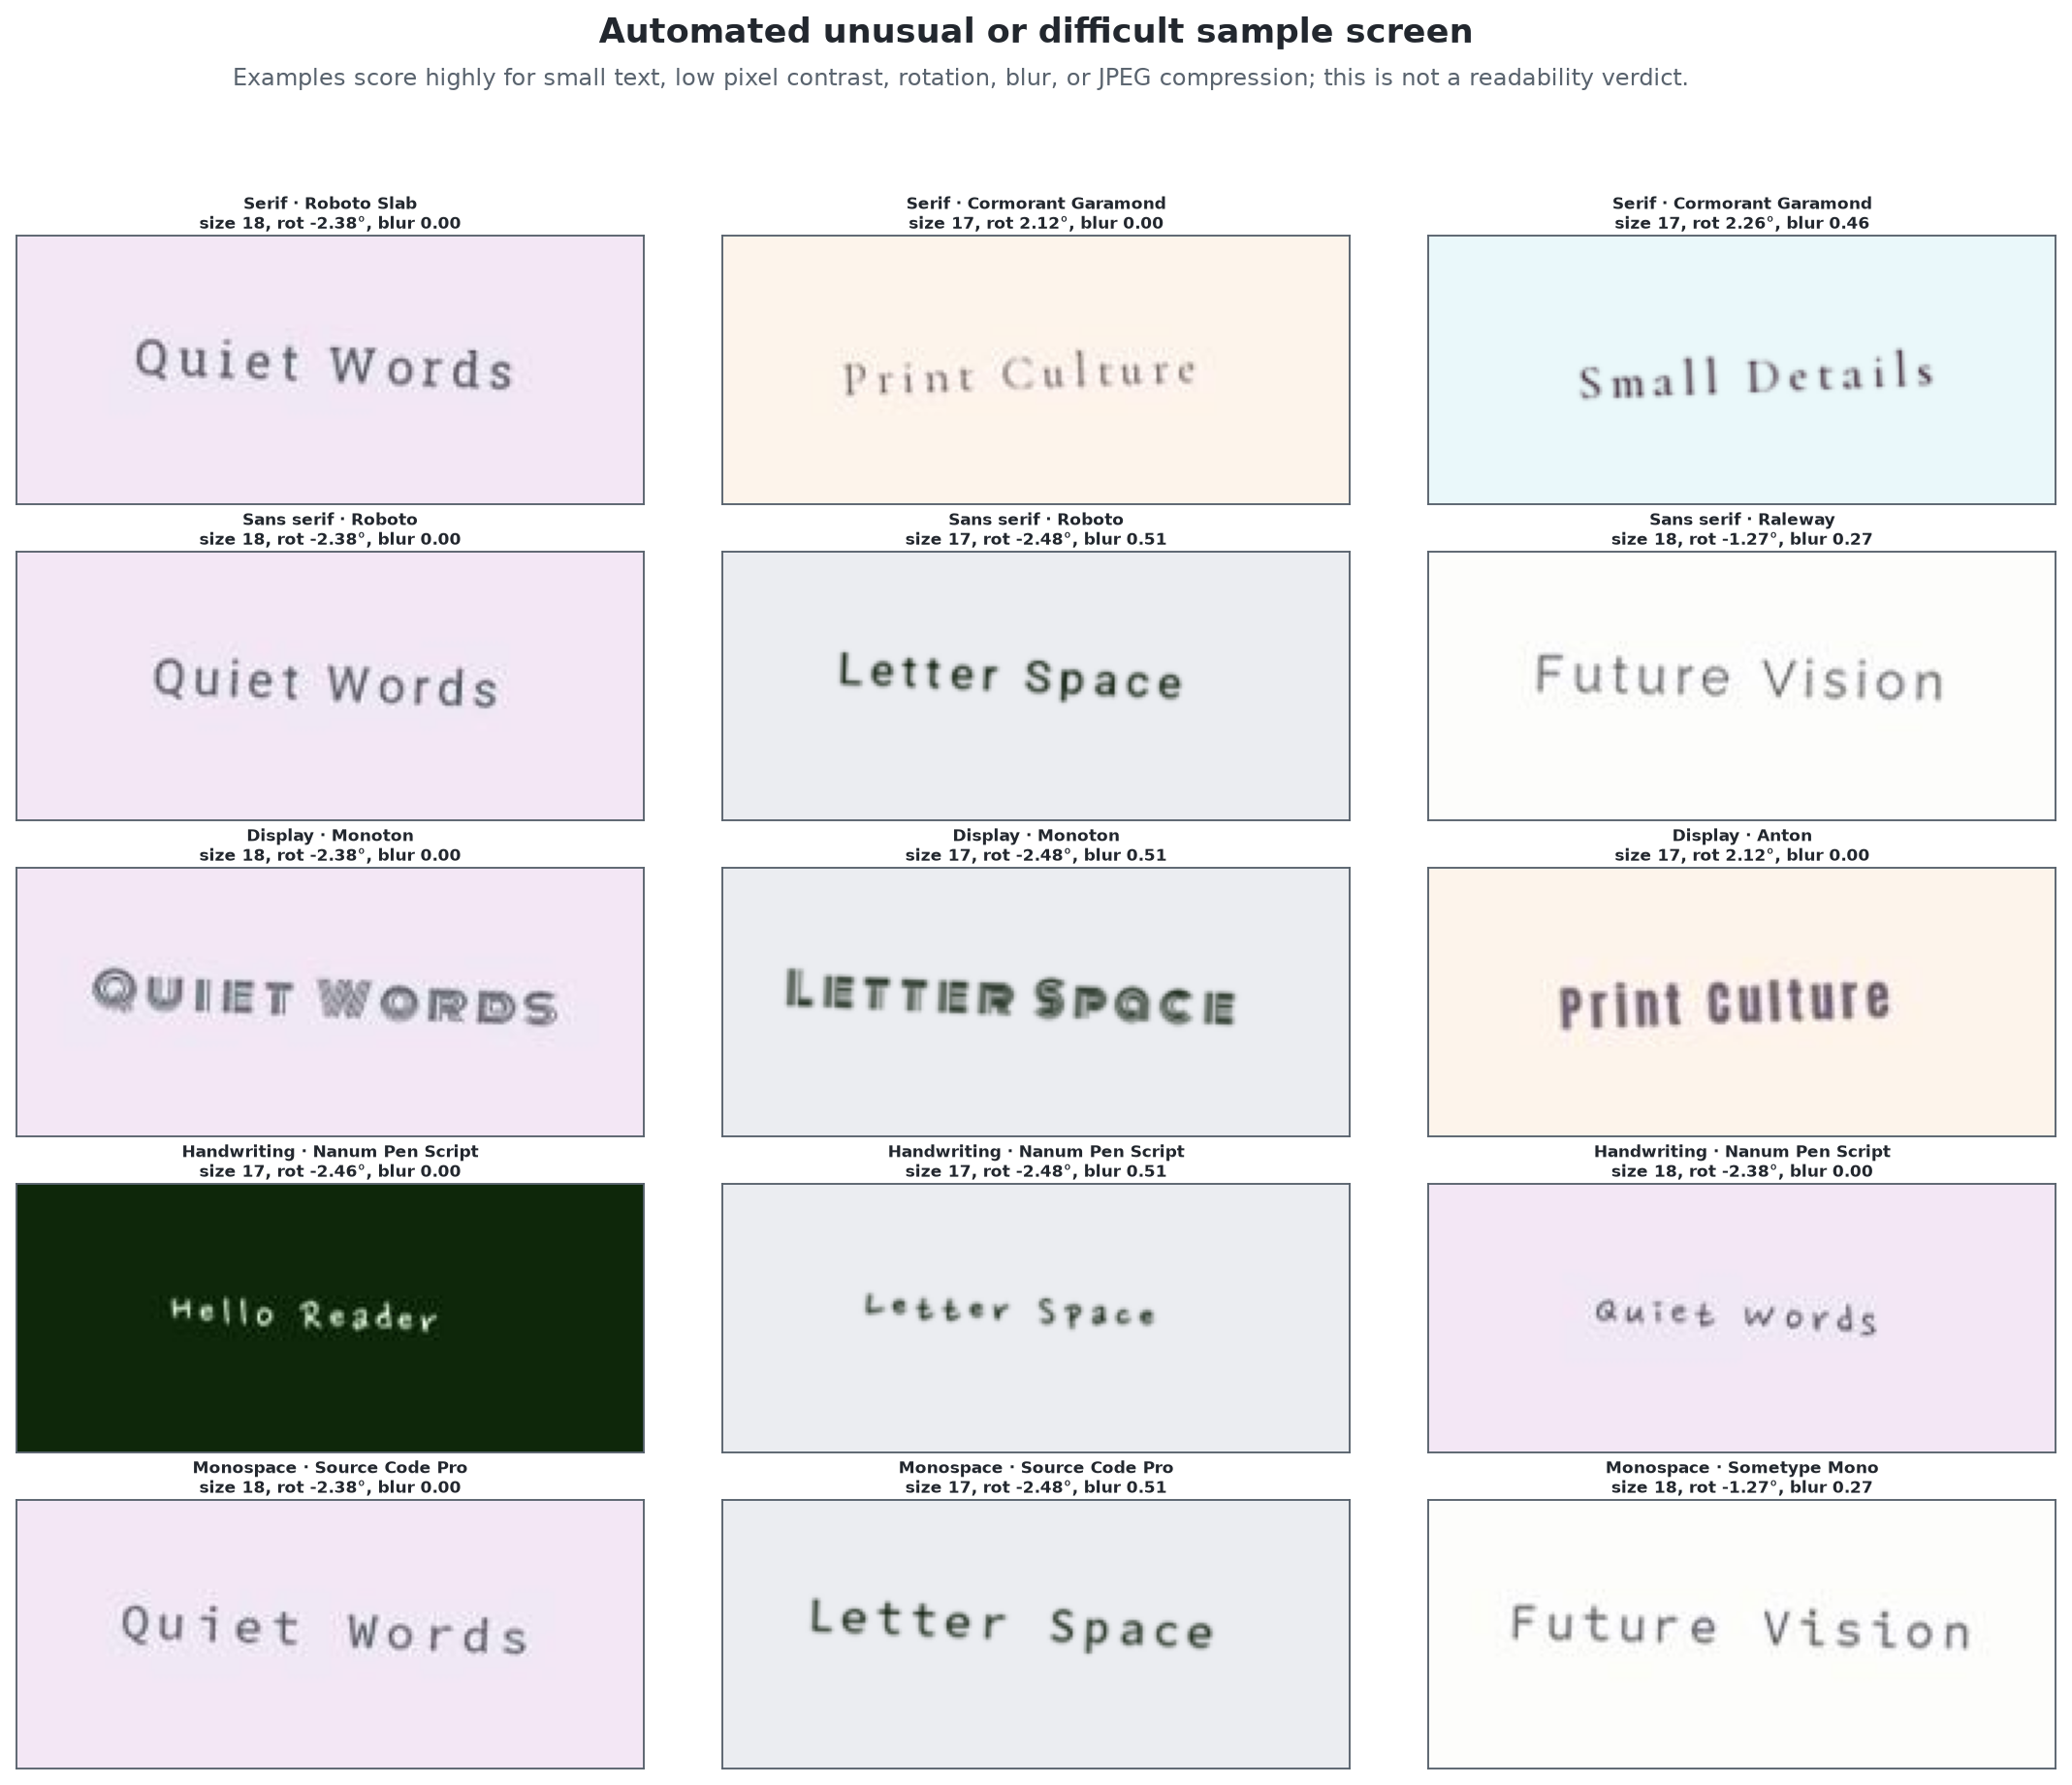

In [21]:
display(NotebookImage(filename=str(FIGURE_DIR / "unusual_difficult_samples.png")))

In [22]:
display(Markdown(
    "**Conclusion.** These are the highest-scoring edge cases under a "
    "conservative difficulty score. They remain openable and non-blank; "
    "the grid is for manual inspection, not an automated readability verdict."
))

**Conclusion.** These are the highest-scoring edge cases under a conservative difficulty score. They remain openable and non-blank; the grid is for manual inspection, not an automated readability verdict.

## Takeaways

The full FontSense dataset passes the requested structural,
file-integrity, leakage, balance, and duplicate checks and is ready
for the next model-development task.

Important limits:

- The data are synthetic renders, so real screenshots may still
  differ in cropping, noise, lighting, and layout.
- Broad font categories can be visually ambiguous.
- Automated readability screening cannot replace human inspection.
- The test split remains reserved for final model evaluation; these
  EDA checks do not report model metrics.